<a href="https://colab.research.google.com/github/hamouda23/Projet-Java/blob/master/Copie_de_a52_projet_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Chargement du fichier CSV
file_path = "assurance.csv"
df = pd.read_csv(file_path)

In [3]:
# Supprimer ID
df.drop('id', axis=1, inplace=True)

In [4]:
# Afficher les premières lignes du dataset
display(df.sample(5))

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
41626,Male,29.0,1.0,16.0,0.0,< 1 Year,Yes,2630.0,152.0,278.0,0.0
77756,Female,22.0,1.0,46.0,1.0,< 1 Year,No,28088.0,152.0,242.0,0.0
2507,Male,43.0,1.0,46.0,1.0,1-2 Year,No,26920.0,124.0,116.0,0.0
112133,Female,25.0,1.0,33.0,1.0,< 1 Year,No,30612.0,152.0,13.0,0.0
47467,Male,69.0,1.0,28.0,0.0,1-2 Year,Yes,49769.0,124.0,94.0,0.0


In [5]:
# Afficher des informations générales sur le dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164947 entries, 0 to 164946
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                164947 non-null  object 
 1   Age                   164946 non-null  float64
 2   Driving_License       164946 non-null  float64
 3   Region_Code           164946 non-null  float64
 4   Previously_Insured    164946 non-null  float64
 5   Vehicle_Age           164946 non-null  object 
 6   Vehicle_Damage        164946 non-null  object 
 7   Annual_Premium        164946 non-null  float64
 8   Policy_Sales_Channel  164946 non-null  float64
 9   Vintage               164946 non-null  float64
 10  Response              164946 non-null  float64
dtypes: float64(8), object(3)
memory usage: 13.8+ MB
None


In [6]:
# Statistiques descriptives pour les variables numériques
display(df.describe())

,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,164946.000000,164946.000000,164946.000000,164946.000000,164946.000000,164946.000000,164946.000000,164946.000000
mean,38.824700,0.997866,26.401337,0.456737,30509.411456,111.981642,154.462818,0.122561
std,15.508607,0.046146,13.234418,0.498126,17208.017157,54.231407,83.712141,0.327934
min,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,25.000000,1.000000,15.000000,0.000000,24376.250000,26.000000,82.000000,0.000000
50%,36.000000,1.000000,28.000000,0.000000,31619.000000,132.500000,154.000000,0.000000
75%,49.000000,1.000000,35.000000,1.000000,39361.000000,152.000000,227.000000,0.000000
max,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [7]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Valeurs manquantes par colonne :
Gender                  0
Age                     1
Driving_License         1
Region_Code             1
Previously_Insured      1
Vehicle_Age             1
Vehicle_Damage          1
Annual_Premium          1
Policy_Sales_Channel    1
Vintage                 1
Response                1
dtype: int64


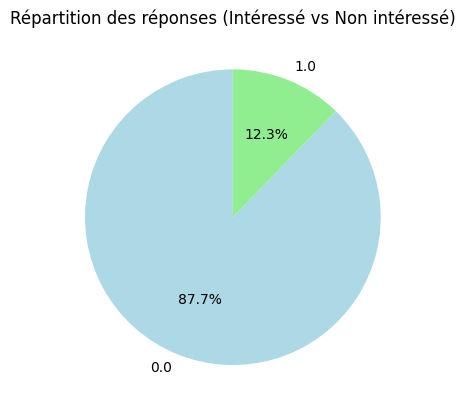

In [8]:
# Correction du diagramme circulaire : utiliser 'Response' au lieu de 'Outcome'
df['Response'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen'])
plt.title('Répartition des réponses (Intéressé vs Non intéressé)')
plt.ylabel('')
plt.show()

In [9]:
# Traitement des valeurs aberrantes pour Annual_Premium
Q1 = df['Annual_Premium'].quantile(0.25)
Q3 = df['Annual_Premium'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Annual_Premium'] >= lower_bound) & (df['Annual_Premium'] <= upper_bound)]
print(f"Nombre de lignes après suppression des outliers pour Annual_Premium : {len(df)}")

Nombre de lignes après suppression des outliers pour Annual_Premium : 160523


In [10]:
# Traitement des valeurs aberrantes pour Driving_License
# On supprime les lignes où Driving_License = 0 (car très rares et potentiellement des erreurs)
df = df[df['Driving_License'] == 1]
print(f"Nombre de lignes après suppression des outliers pour Driving_License : {len(df)}")

Nombre de lignes après suppression des outliers pour Driving_License : 160192


In [11]:
# Encodage des colonnes catégoriques
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['Vehicle_Damage'] = df['Vehicle_Damage'].map({'Yes': 1, 'No': 0})
df['Vehicle_Age'] = df['Vehicle_Age'].map({'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2})
print("Aperçu après encodage :")
display(df.head())

Aperçu après encodage :


,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,0,44.0,1.0,28.0,0.0,2,1,40454.0,26.0,217.0,1.0
1,0,76.0,1.0,3.0,0.0,1,0,33536.0,26.0,183.0,0.0
2,0,47.0,1.0,28.0,0.0,2,1,38294.0,26.0,27.0,1.0
3,0,21.0,1.0,11.0,1.0,0,0,28619.0,152.0,203.0,0.0
4,1,29.0,1.0,41.0,1.0,0,0,27496.0,152.0,39.0,0.0


In [12]:
# Sauvegarde du jeu de données propre
df.to_csv('assurance_clean.csv', index=False)
print("Jeu de données propre sauvegardé sous 'assurance_clean.csv'")

Jeu de données propre sauvegardé sous 'assurance_clean.csv'
